In [3]:
import pandas as pd

df = pd.read_csv("house_dataset_sample.csv")

# Question 2: Data cleaning
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].mean())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].mean())

# Drop columns if they exist
for col in ["id", "Unnamed: 0"]:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print(df.describe())

               price  bedrooms  bathrooms  sqft_living    floors  waterfront  \
count       5.000000  5.000000   5.000000     5.000000  5.000000         5.0   
mean   410780.000000  3.000000   1.850000  1632.000000  1.200000         0.0   
std    195127.245663  0.707107   0.858778   695.895107  0.447214         0.0   
min    180000.000000  2.000000   1.000000   770.000000  1.000000         0.0   
25%    221900.000000  3.000000   1.000000  1180.000000  1.000000         0.0   
50%    510000.000000  3.000000   2.000000  1680.000000  1.000000         0.0   
75%    538000.000000  3.000000   2.250000  1960.000000  1.000000         0.0   
max    604000.000000  4.000000   3.000000  2570.000000  2.000000         0.0   

          grade  
count  5.000000  
mean   7.000000  
std    0.707107  
min    6.000000  
25%    7.000000  
50%    7.000000  
75%    7.000000  
max    8.000000  


In [5]:
df["floors"].value_counts().to_frame()


,count
floors,
1.0,4
2.0,1


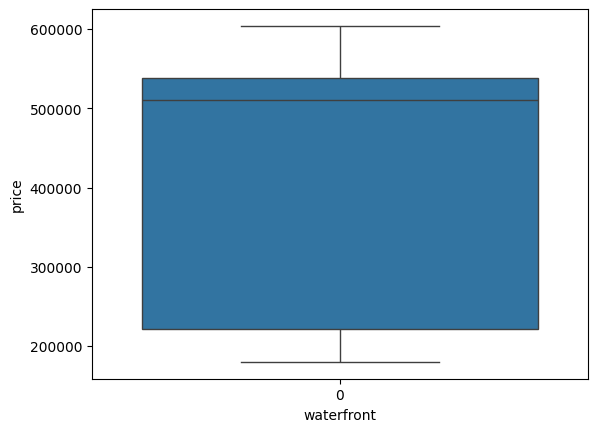

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="waterfront", y="price", data=df)
plt.show()

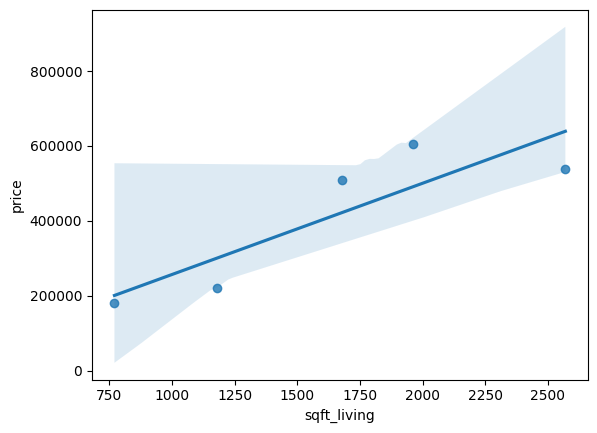

In [7]:
sns.regplot(x="sqft_living", y="price", data=df)
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

X = df[["sqft_living"]]
y = df["price"]

lm = LinearRegression()
lm.fit(X, y)

print("R2 =", lm.score(X, y))

R2 = 0.754450099296162


In [9]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "floors",
    "waterfront",
    "grade"
]

X = df[features]
y = df["price"]

lm = LinearRegression()
lm.fit(X, y)

print("R2 =", lm.score(X, y))

R2 = 1.0


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(X, y)

print("Pipeline R2 =", pipe.score(X, y))

Pipeline R2 = 1.0


In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Ridge Test R2 =", ridge.score(X_test, y_test))

Ridge Test R2 = nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

print("Polynomial Ridge R2 =", ridge.score(X_test_poly, y_test))

Polynomial Ridge R2 = nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
